# 고객 군집 분석 실습
- 실습 순서
1. 거래 데이터 확인
2. 결측치, 취소 거래, 비정상 거래 정리
3. 고객별 RFM 지표 생성
4. 데이터 스케일링 및 군집 수 선택
5. K-Means 군집화
6. 군집별 고객 특성 해석
7. 마케팅 관점에서 고객군 이름, 혜택 등 추가

1. 라이브러리 불러오기

In [17]:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

SEED = 42
sns.set_theme(style='whitegrid')

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [18]:
retail_df = pd.read_excel('data/Online Retail.xlsx')
retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [19]:
origin_df = retail_df.copy()

In [20]:
retail_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [21]:
retail_df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [22]:
retail_df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


Quantity, UnitPrice에 있는 음수는 처리 필요  
CustomerID가 없는 데이터는 삭제 처리

In [23]:
cancle_count = retail_df['InvoiceNo'].astype(str).str.startswith('C').sum()
negative_quantity_count = (retail_df['Quantity'] <= 0).sum()
non_positive_price_count = (retail_df['UnitPrice'] <= 0).sum()

print(f'취소 거래 수: {cancle_count}')
print(f'수량 0 이하 거래 수: {negative_quantity_count}')
print(f'단가 0 이하 거래 수: {non_positive_price_count}')

취소 거래 수: 9288
수량 0 이하 거래 수: 10624
단가 0 이하 거래 수: 2517


4. 데이터 전처리
- CustomerID 없는 거래 제거
- 취소된 거래 제거
- Quantity 0 이하인 거래 제거
- UnitPrice 0 이하인 거래 제거
- CustomerID 정수형 변환
- 거래금액 파생변수 sale_amount = Quantity * UnitPrice

In [28]:
df_clean = retail_df.copy()
df_clean = df_clean.dropna(subset=['CustomerID'])
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['sale_amount'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,sale_amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [30]:
print(f'전처리 전: {retail_df.shape}')
print(f'전처리 후: {df_clean.shape}')

전처리 전: (541909, 8)
전처리 후: (397884, 9)


In [31]:
preprocessed_df = df_clean.copy()

5. 주요 변수 이상치 확인

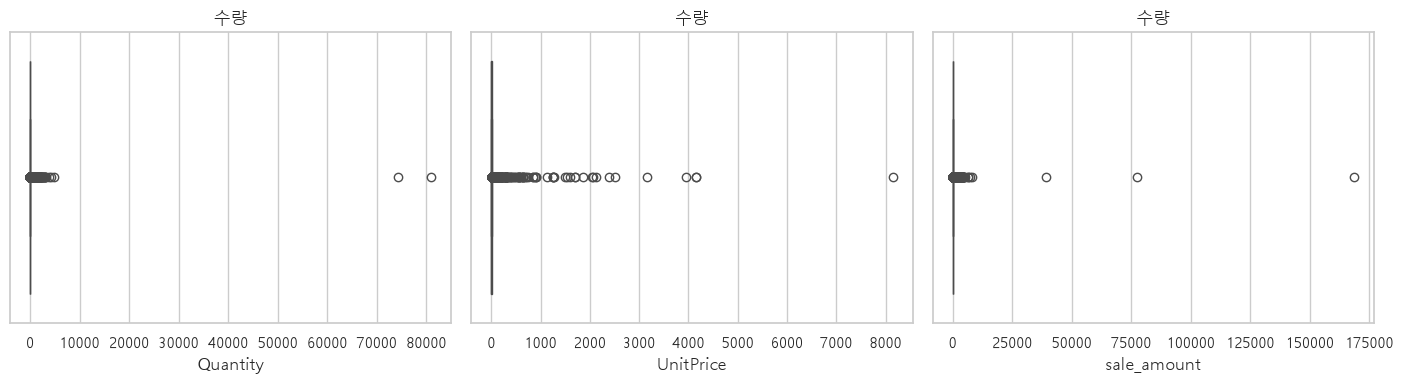

In [33]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
sns.boxplot(x=df_clean['Quantity'])
plt.title('수량')

plt.subplot(1, 3, 2)
sns.boxplot(x=df_clean['UnitPrice'])
plt.title('수량')

plt.subplot(1, 3, 3)
sns.boxplot(x=df_clean['sale_amount'])
plt.title('수량')

plt.tight_layout()
plt.show()

소수 고객의 구매 금액이 매우 큰 경우가 많음  
실제 데이터이기 때문에 IQR 이상치 제거보다는 로그변환정도 하면 약간 분포를 눌러줄 수 있음

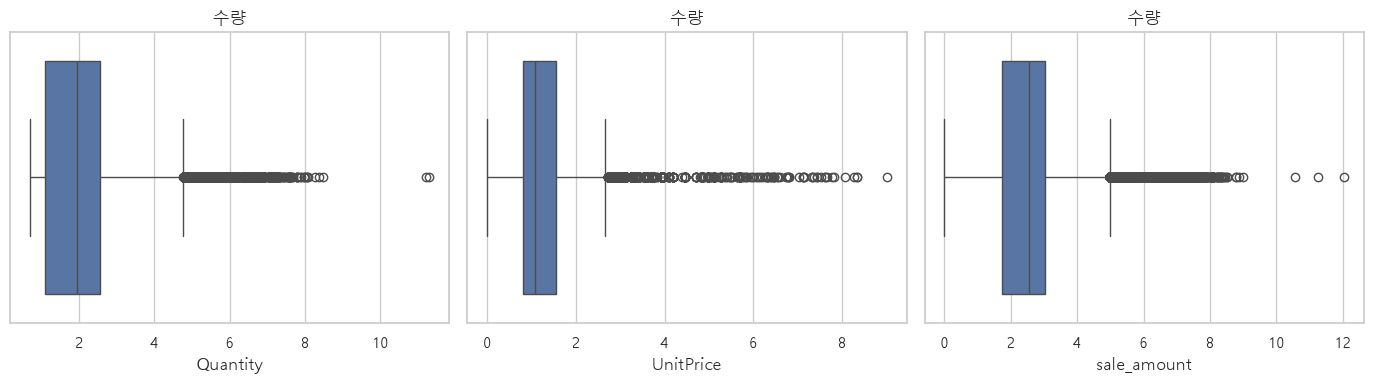

In [37]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
sns.boxplot(x=np.log1p(df_clean['Quantity']))
plt.title('수량')

plt.subplot(1, 3, 2)
sns.boxplot(x=np.log1p(df_clean['UnitPrice']))
plt.title('수량')

plt.subplot(1, 3, 3)
sns.boxplot(x=np.log1p(df_clean['sale_amount']))
plt.title('수량')

plt.tight_layout()
plt.show()

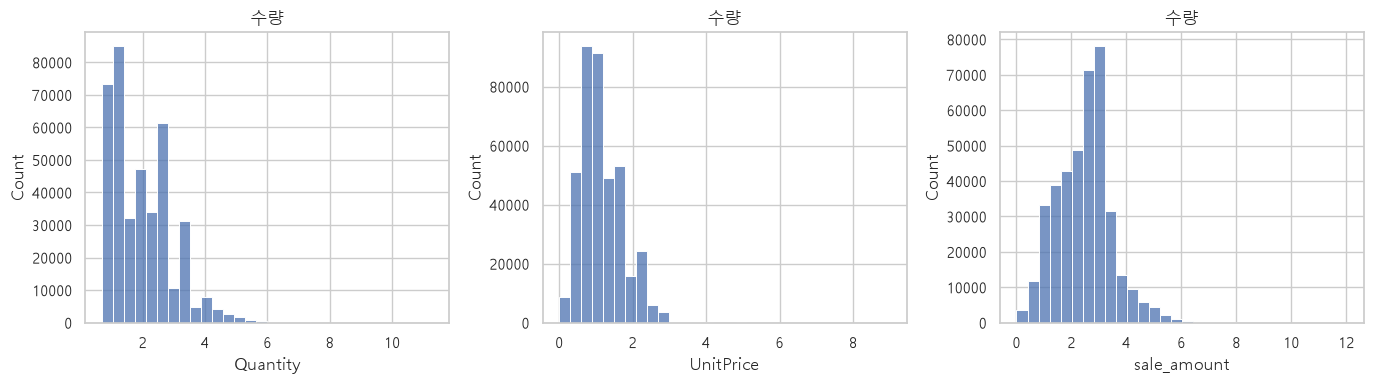

In [38]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
sns.histplot(np.log1p(df_clean['Quantity']), bins=30)
plt.title('수량')

plt.subplot(1, 3, 2)
sns.histplot(np.log1p(df_clean['UnitPrice']), bins=30)
plt.title('수량')

plt.subplot(1, 3, 3)
sns.histplot(np.log1p(df_clean['sale_amount']), bins=30)
plt.title('수량')

plt.tight_layout()
plt.show()

6. 국가별 거래 현황 확인

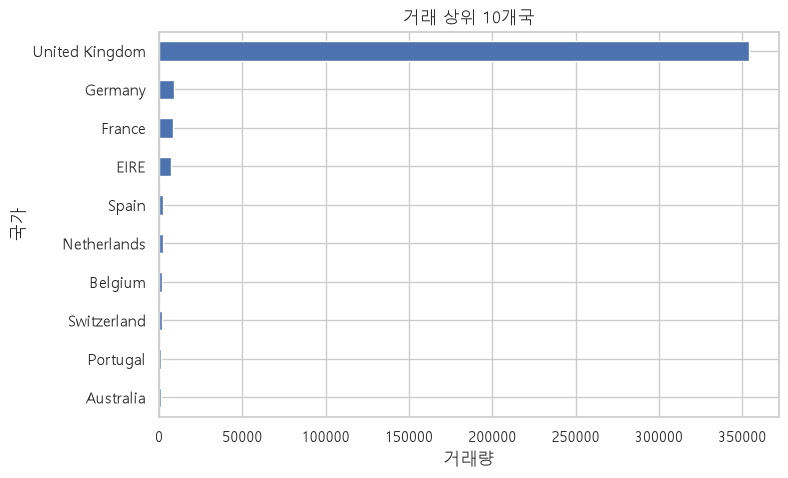

In [39]:
country_counts = df_clean['Country'].value_counts().head(10)

plt.figure(figsize=(8, 5))
country_counts.sort_values().plot(kind='barh')
plt.title('거래 상위 10개국')
plt.xlabel('거래량')
plt.ylabel('국가')
plt.show()

In [42]:
customer_sales = df_clean.groupby('CustomerID')['sale_amount'].sum().sort_values(ascending=False)
customer_sales.head(10).to_frame()

,sale_amount
CustomerID,
14646,280206.02
18102,259657.30
17450,194550.79
16446,168472.50
14911,143825.06
12415,124914.53
14156,117379.63
17511,91062.38
16029,81024.84


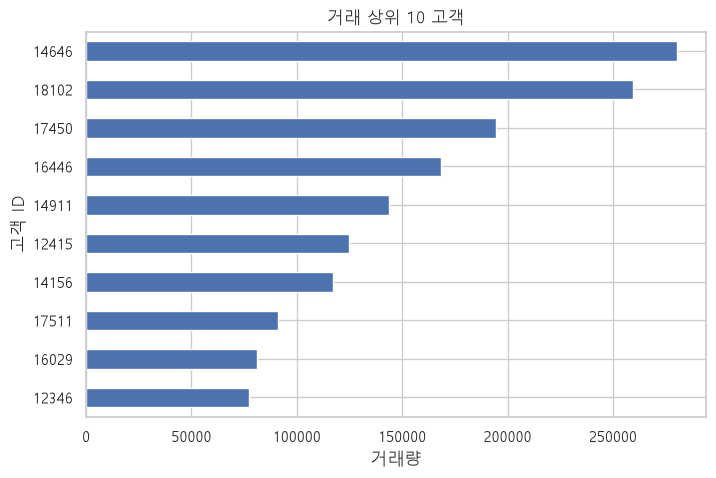

In [43]:
top10 = customer_sales.head(10).sort_values()

plt.figure(figsize=(8, 5))
top10.plot(kind='barh')
plt.title('거래 상위 10 고객')
plt.xlabel('거래량')
plt.ylabel('고객 ID')
plt.show()

In [52]:
# 상위 10% 고객이 차지하는 매출 비중 계산
total_customers = customer_sales.shape[0]
top_10_percent_cnt = max(1, int(total_customers * 0.1))

top_10_sales = customer_sales.iloc[:top_10_percent_cnt].sum()
total_sales = customer_sales.sum()
top_10_ratio = top_10_sales / total_sales

print(f'전체 고객 수: {total_customers}')
print(f'상위 10% 고객 수: {top_10_percent_cnt}')
print(f'상위 10% 고객 매출 비중: {round(top_10_ratio, 4)}')

전체 고객 수: 4338
상위 10% 고객 수: 433
상위 10% 고객 매출 비중: 0.6133


고객 집단을 나눠 관리하는 것이 효율적일 것  
고매출 집단 -> 유지 전략  
저매출 집단 -> 방문 유도 전략

8. RFM 데이터 만들기
Recency 지표 (최근 구매일로부터 지난 일수): 작을수록 최근 구매한 고객  
Frequency 지표 (구매횟수): 클수록 자주 구매한 고객  
Monetary 지표 (총 구매 금액): 클수록 매출 기여도가 큰 고객

In [54]:
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [56]:
rfm_df = (
    df_clean.groupby('CustomerID').agg(
        Recency = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
        Frequency = ('InvoiceNo', 'nunique'),
        Monetary = ('sale_amount', 'sum')
    ).reset_index()
)

rfm_df = rfm_df[rfm_df['Monetary'] > 0]
rfm_df

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
...,...,...,...,...
4333,18280,278,1,180.60
4334,18281,181,1,80.82
4335,18282,8,2,178.05
4336,18283,4,16,2094.88


In [57]:
rfm_df[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


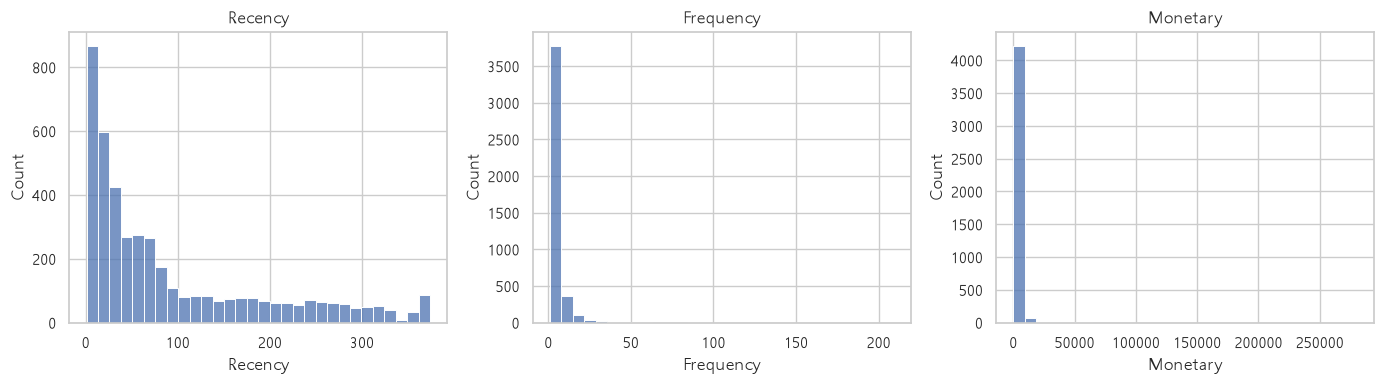

In [59]:
plt.figure(figsize=(14, 4))

for idx, col in enumerate(['Recency', 'Frequency', 'Monetary'], 1):
    plt.subplot(1, 3, idx)
    sns.histplot(rfm_df[col], bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

Monetary는 일부 고객이 매우 큰 값을 가져 K-Means 같은 거리기반 알고리즘에 적용하면 변수 영향 지나치게 커질 위험 존재  
그래서 log1p()로 분포 완화하고, StandardScaler로 스케일링 작업 진행

9. 로그 변환과 스케일링
- log1p()로 치우친 분포 완화
- StandardScaler로 평균 0, 표준편차 1 형태로 변환

In [60]:
rfm_features = ['Recency', 'Frequency', 'Monetary']

rfm_log = rfm_df[rfm_features].apply(np.log1p)

rfm_log.head()

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


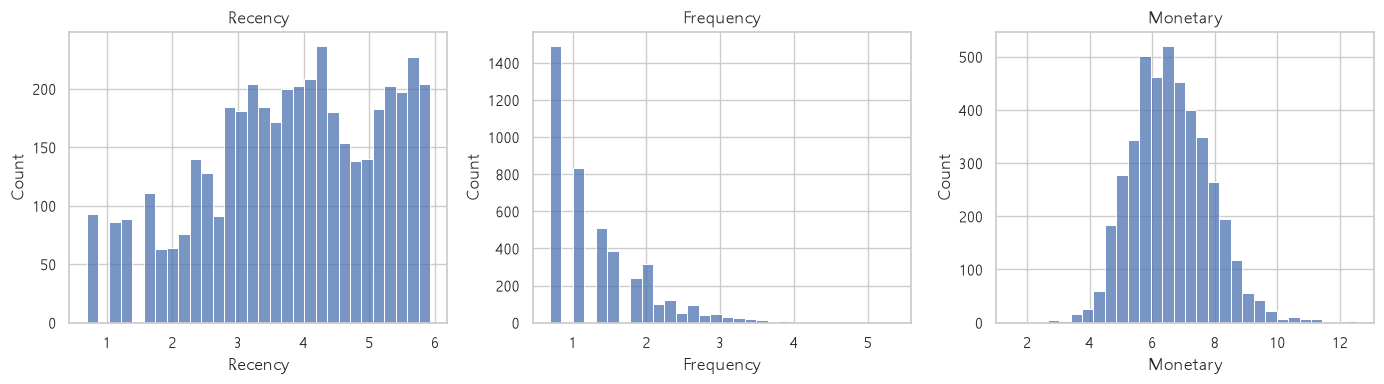

In [61]:
plt.figure(figsize=(14, 4))

for idx, col in enumerate(rfm_features, 1):
    plt.subplot(1, 3, idx)
    sns.histplot(rfm_log[col], bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

In [62]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(rfm_log)
scaled_data

array([[ 1.46199281, -0.95521426,  3.70622476],
       [-2.03873442,  1.07442519,  1.41184341],
       [ 0.37310424,  0.38630445,  0.7164889 ],
       ...,
       [-1.21893976, -0.36158278, -1.11812113],
       [-1.65755161,  2.17800394,  0.83829669],
       [-0.03473174,  0.05960547,  0.73400231]], shape=(4338, 3))

10. 적절한 군집 수 K개 선택하기
- 두 개의 기준
    - Elbow Method: 군집 내 거리 합이 급격하게 줄어드는 지점 확인
    - Silhouette Score: 군집이 얼마나 잘 분리되었는지 확인

- 실제로는 해석 가능성 + 비즈니스 활용 가능성 추가

In [67]:
k_values = range(2, 9)

inertia_list = []
silhouette_list = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = kmeans.fit_predict(scaled_data)

    inertia_list.append(kmeans.inertia_)

    sample_size = min(1000, len(scaled_data))
    score = silhouette_score(
        scaled_data,
        labels,
        sample_size=sample_size,
        random_state=SEED
    )

    silhouette_list.append(score)

k_result = pd.DataFrame({
    'k': list(k_values),
    'inertia': inertia_list,
    'silhouette_score': silhouette_list
})
k_result

,k,inertia,silhouette_score
0,2,6481.225323,0.429084
1,3,4867.846645,0.332634
2,4,3938.509954,0.334941
3,5,3295.976329,0.317371
4,6,2855.011247,0.317349
5,7,2548.914324,0.311720
6,8,2336.777508,0.298899


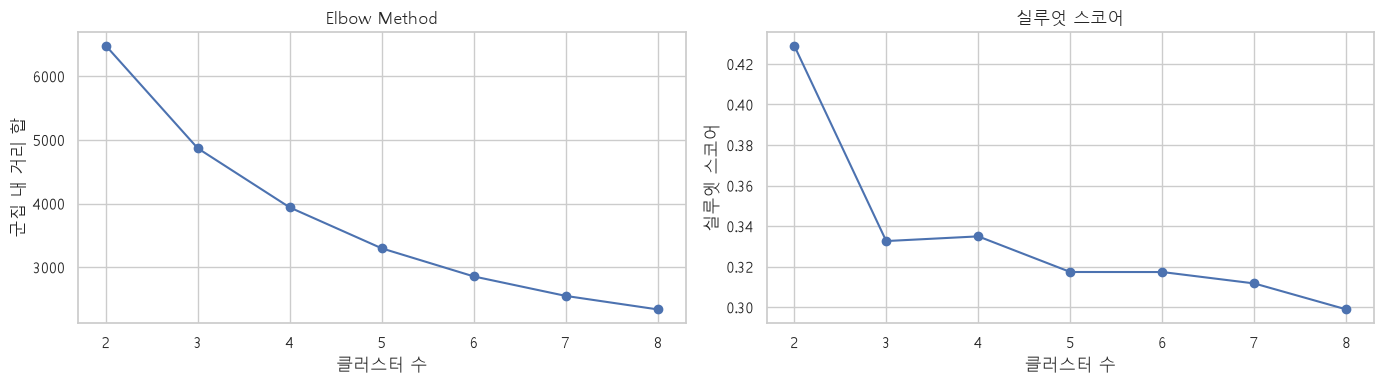

In [ ]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(k_result['k'], k_result['inertia'], marker='o')
plt.title('Elbow Method')
plt.xlabel('클러스터 수')
plt.ylabel('군집 내 거리 합')

plt.subplot(1, 2, 2)
plt.plot(k_result['k'], k_result['silhouette_score'], marker='o')
plt.title('실루엇 스코어')
plt.xlabel('클러스터 수')
plt.ylabel('실루엣 스코어')

plt.tight_layout()
plt.show()

지표상 k=4가 적절  
해석상 편의 위해 k=3으로 진행

11. K-Means 군집화

In [71]:
K = 3

kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=10)
rfm_df['cluster'] = kmeans.fit_predict(scaled_data)

rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,cluster
0,12346,326,1,77183.60,2
1,12347,2,7,4310.00,0
2,12348,75,4,1797.24,2
3,12349,19,1,1757.55,2
4,12350,310,1,334.40,1


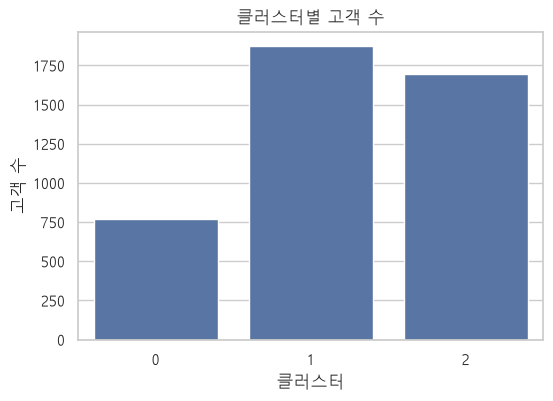

In [77]:
cluster_counts = rfm_df['cluster'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values)
plt.title('클러스터별 고객 수')
plt.xlabel('클러스터')
plt.ylabel('고객 수')
plt.show()

In [78]:
final_silhouette = silhouette_score(scaled_data, rfm_df['cluster'], sample_size=min(1000, len(scaled_data)), random_state=SEED)
final_silhouette

0.3326339810525557

silhouette_score = 1 ~ -1  
1에 가까울수록 분리 잘 됨  
0에 가까울수록 경계 모호  
-1에 가까울수록 다른 군집과 더 가까운 데이터 많음

0.33.. -> 낮진 않지만 코객 데이터 특성상 패턴이 연속적인 면이 있어 점수 안 좋게 나옴

In [79]:
pca = PCA(n_components=2, random_state=SEED)
pca_data = pca.fit_transform(scaled_data)

rfm_df['pca_x'] = pca_data[:, 0]
rfm_df['pca_y'] = pca_data[:, 1]

print(f'PCA 1, 2축 설명 분산 비율: {pca.explained_variance_ratio_}')
print(f'PCA 누적 설명 분산 비율: {pca.explained_variance_ratio_.sum()}')

PCA 1, 2축 설명 분산 비율: [0.75102042 0.18759201]
PCA 누적 설명 분산 비율: 0.9386124314129808


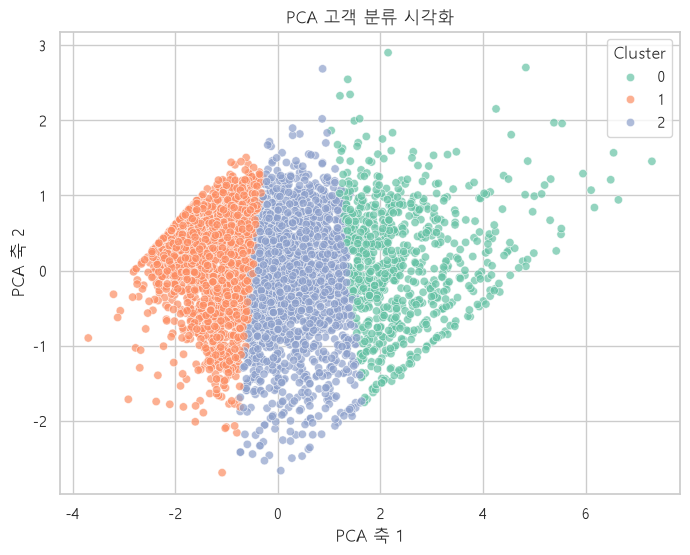

In [81]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=rfm_df,
    x='pca_x',
    y='pca_y',
    hue='cluster',
    palette='Set2',
    alpha=0.7
)

plt.title('PCA 고객 분류 시각화')
plt.xlabel('PCA 축 1')
plt.ylabel('PCA 축 2')
plt.legend(title='Cluster')
plt.show()

군집 간 차이가 비교적 명확하게 분리됨  
겹치는 부분은 고객의 행동 양식이 연속적인 경우

13. 군집별 RFM 특성 해석
- 각 군집이 어떤 고객군인지 해석

In [87]:
cluster_summary = (
    rfm_df.groupby('cluster').agg(
        customer_count=('CustomerID', 'count'),
        recency_mean = ('Recency', 'mean'),
        recency_median = ('Recency', 'median'),
        frequency_mean = ('Frequency', 'mean'),
        frequency_median = ('Frequency', 'median'),
        monetary_mean = ('Monetary', 'mean'),
        monetary_median = ('Monetary', 'median'),
        monetary_sum = ('Monetary', 'sum'),
    ).round(2)
)

cluster_summary.T

cluster,0,1,2
customer_count,770.00,1872.00,1696.00
recency_mean,17.06,167.36,44.21
recency_median,9.00,158.00,30.00
frequency_mean,13.34,1.35,3.38
frequency_median,10.00,1.00,3.00
monetary_mean,7905.44,362.54,1265.06
monetary_median,3708.34,298.06,979.19
monetary_sum,6087189.20,678670.41,2145548.29


recency 높다 -> 최근 구매 고객  
frequency 높다 -> 자주 구매한 고객  
monetary 높다 -> 구매 금액 큰 고객

Cluster 0이 VIP  
Cluster 1이 휴면고객  
Cluster 2이 일반고객


In [89]:
cluster_profile = rfm_df.groupby('cluster')[rfm_features].mean()
cluster_profile

,Recency,Frequency,Monetary
cluster,,,
0,17.063636,13.338961,7905.440519
1,167.361111,1.352030,362.537613
2,44.212264,3.378538,1265.063852


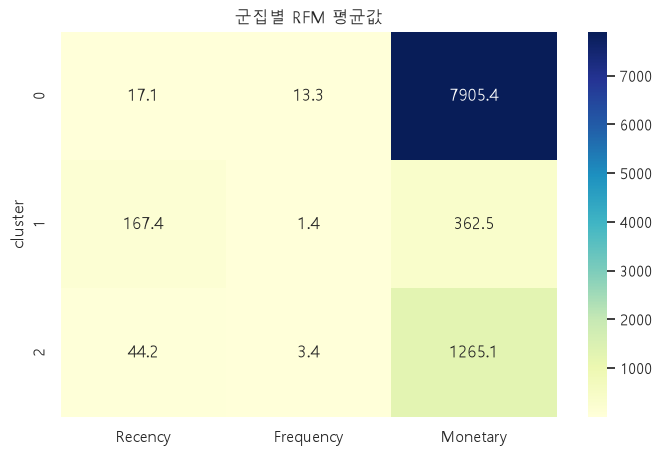

In [ ]:
# 군집별 RFM 평균값 시각화
plt.figure(figsize=(8, 5))
sns.heatmap(
    cluster_profile,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu'
)
plt.title('군집별 RFM 평균값')
plt.show()

14. 군집 이름 붙이기

In [94]:
def assign_segment_name(row, summary):
    recency_rank = summary['recency_mean'].rank(ascending=True)
    frequency_rank = summary['frequency_mean'].rank(ascending=False)
    monetary_rank = summary['monetary_mean'].rank(ascending=False)

    cluster_id = row.name

    if (
        recency_rank.loc[cluster_id] == 1 and
        frequency_rank.loc[cluster_id] <= 2 and
        monetary_rank.loc[cluster_id] <= 2
    ):
        return 'VIP / 핵심 고객'
    
    if recency_rank.loc[cluster_id] == recency_rank.max():
        return '이탈 위험 고객'
    
    return '일반 / 성장 가능 고객'

cluster_summary['segment_name'] = cluster_summary.apply(
    lambda row: assign_segment_name(row, cluster_summary),
    axis=1
)

cluster_summary.T

cluster,0,1,2
customer_count,770,1872,1696
recency_mean,17.06,167.36,44.21
recency_median,9.0,158.0,30.0
frequency_mean,13.34,1.35,3.38
frequency_median,10.0,1.0,3.0
monetary_mean,7905.44,362.54,1265.06
monetary_median,3708.34,298.06,979.19
monetary_sum,6087189.2,678670.41,2145548.29
segment_name,VIP / 핵심 고객,이탈 위험 고객,일반 / 성장 가능 고객


In [95]:
segment_map = cluster_summary['segment_name'].to_dict()
segment_map

{0: 'VIP / 핵심 고객', 1: '이탈 위험 고객', 2: '일반 / 성장 가능 고객'}

In [97]:
rfm_df['segment_name'] = rfm_df['cluster'].map(segment_map)
rfm_df.head().T

,0,1,2,3,4
CustomerID,12346,12347,12348,12349,12350
Recency,326,2,75,19,310
Frequency,1,7,4,1,1
Monetary,77183.6,4310.0,1797.24,1757.55,334.4
cluster,2,0,2,2,1
pca_x,0.872658,2.55026,0.475142,0.145832,-1.68899
pca_y,2.686758,-0.804427,0.746121,-0.46048,0.676555
segment_name,일반 / 성장 가능 고객,VIP / 핵심 고객,일반 / 성장 가능 고객,일반 / 성장 가능 고객,이탈 위험 고객


15. 마케팅 전략 예시

In [99]:
marketing_strategy = pd.DataFrame({
    'segment_name': [
        'VIP / 핵심 고객',
        '일반 / 성장 가능 고객',
        '이탈 위험 고객'
    ],
    'interpretations': [
        '최근 구매 있고, 구매 빈도와 금액 높은 우수 고객군',
        '현재 구매 규모는 중간 수준이지만 추가 구매 가능성 존재하는 고객군',
        '마지막 구매 후 시간 오래 지나 재방문 유도가 필요한 고객군'
    ],
    'strategy': [
        '멤버쉽 혜택, 신상품 선공개, 감사 쿠폰 제공, VIP 라운지 등 특별한 공간 제공',
        '추천 상품, 묶음 할인, 재구매 쿠폰 제공',
        '휴면 고객 리마인드, 복귀 쿠폰, 이메일 캠페인 진행'
    ]
})

marketing_strategy

,segment_name,interpretations,strategy
0,VIP / 핵심 고객,"최근 구매 있고, 구매 빈도와 금액 높은 우수 고객군","멤버쉽 혜택, 신상품 선공개, 감사 쿠폰 제공, VIP 라운지 등 특별한 공간 제공"
1,일반 / 성장 가능 고객,현재 구매 규모는 중간 수준이지만 추가 구매 가능성 존재하는 고객군,"추천 상품, 묶음 할인, 재구매 쿠폰 제공"
2,이탈 위험 고객,마지막 구매 후 시간 오래 지나 재방문 유도가 필요한 고객군,"휴면 고객 리마인드, 복귀 쿠폰, 이메일 캠페인 진행"


고객군 나누기
- 거래 데이터를 고객 단위 RFM 데이터로 변환
- 로그 변환과 스케일링으로 거리 기반 군집화 준비
- Elbow Method, Silhouette Score로 K 후보군 확인
- K-Means로 고객군 분류
- 군집별 RFM 특성 해석하고 고객군 이름 부여
- 고객군별 마케팅 전략 제안

군집 분석은 모델 결과가 중요하기보다는 결과 해석이나 활용 전략이 더 중요한 부분 차지

- 추가 고도화 과제
1. DBSCAN or GMM으로 군집화 비교
2. RFM을 점수화해서 고객 등급 다시 만들어보기
3. RFM 지표를 추가해보기
4. 시각화 위한 차원축소 PCA -> t-SNE나 UMAP
5. 고객 ID 입력하거나 RFM 정보 등 입력 시 고객군과 추천 전략 출력하는 함수